In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
    

### Data Preprocessing


In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'dataset-2/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="training",
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
    
)

Found 43456 files belonging to 38 classes.
Using 34765 files for training.


In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'dataset-2/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="validation",
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
)

Found 43456 files belonging to 38 classes.
Using 8691 files for validation.


In [5]:
training_set


<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

## Building Model

In [6]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [7]:
model= Sequential()

In [8]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [9]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(Dropout(0.25))

In [13]:
model.add(Flatten())

In [14]:
model.add(Dense(units=1500,activation='relu'))

In [15]:
model.add(Dropout(0.4))

In [16]:
model.add(Dense(units=38,activation='softmax'))

## Compiling Model

In [17]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

## Model Training

In [19]:
training_history= model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
1087/1087 [==============================] - 90s 63ms/step - loss: 1.1690 - accuracy: 0.6634 - val_loss: 0.5714 - val_accuracy: 0.8128
Epoch 2/10
1087/1087 [==============================] - 68s 62ms/step - loss: 0.4524 - accuracy: 0.8577 - val_loss: 0.3350 - val_accuracy: 0.8882
Epoch 3/10
1087/1087 [==============================] - 68s 62ms/step - loss: 0.2756 - accuracy: 0.9109 - val_loss: 0.2400 - val_accuracy: 0.9218
Epoch 4/10
1087/1087 [==============================] - 68s 62ms/step - loss: 0.1924 - accuracy: 0.9361 - val_loss: 0.2078 - val_accuracy: 0.9318
Epoch 5/10
1087/1087 [==============================] - 68s 62ms/step - loss: 0.1336 - accuracy: 0.9552 - val_loss: 0.3056 - val_accuracy: 0.9074
Epoch 6/10
1087/1087 [==============================] - 68s 63ms/step - loss: 0.1102 - accuracy: 0.9646 - val_loss: 0.2153 - val_accuracy: 0.9410
Epoch 7/10
1087/1087 [==============================] - 68s 63ms/step - loss: 0.0912 - accuracy: 0.9693 - val_loss: 0.1481 -

## Model Evaluation

In [20]:
train_loss,train_acc= model.evaluate(training_set)

1087/1087 [==============================] - 27s 25ms/step - loss: 0.0209 - accuracy: 0.9934


In [21]:
print(train_loss,train_acc)

0.020912785083055496 0.9933841228485107


In [22]:
val_loss,val_acc=model.evaluate(validation_set)

272/272 [==============================] - 7s 25ms/step - loss: 0.1719 - accuracy: 0.9516


In [23]:
print(val_loss,val_acc)

0.17191573977470398 0.9515590667724609


## Saving Model

In [24]:
model.save("trained_model.keras")

In [25]:
training_history.history

{'loss': [1.1689743995666504,
  0.45235201716423035,
  0.2756081521511078,
  0.19238100945949554,
  0.1336418241262436,
  0.11016318202018738,
  0.09119078516960144,
  0.08002931624650955,
  0.06768104434013367,
  0.05771893262863159],
 'accuracy': [0.6633970737457275,
  0.8577304482460022,
  0.910944938659668,
  0.9361138939857483,
  0.955184817314148,
  0.964590847492218,
  0.9693081974983215,
  0.9730188250541687,
  0.9773047566413879,
  0.9818495512008667],
 'val_loss': [0.5713845491409302,
  0.33501577377319336,
  0.2399708479642868,
  0.20775286853313446,
  0.30564525723457336,
  0.21530771255493164,
  0.14806944131851196,
  0.2631969153881073,
  0.18173566460609436,
  0.1719156801700592],
 'val_accuracy': [0.8127948641777039,
  0.8881601691246033,
  0.9217581152915955,
  0.9317684769630432,
  0.9073754549026489,
  0.9409734010696411,
  0.9566217660903931,
  0.9253250360488892,
  0.9510988593101501,
  0.9515590667724609]}

In [26]:
training_history.history['accuracy']

[0.6633970737457275,
 0.8577304482460022,
 0.910944938659668,
 0.9361138939857483,
 0.955184817314148,
 0.964590847492218,
 0.9693081974983215,
 0.9730188250541687,
 0.9773047566413879,
 0.9818495512008667]

In [27]:
training_history.history['val_accuracy']

[0.8127948641777039,
 0.8881601691246033,
 0.9217581152915955,
 0.9317684769630432,
 0.9073754549026489,
 0.9409734010696411,
 0.9566217660903931,
 0.9253250360488892,
 0.9510988593101501,
 0.9515590667724609]

In [50]:
#Recording History 
import json
with open("training_history.json","w") as f:
    json.dump(training_history.history,f)

## Accuracy Visualisation

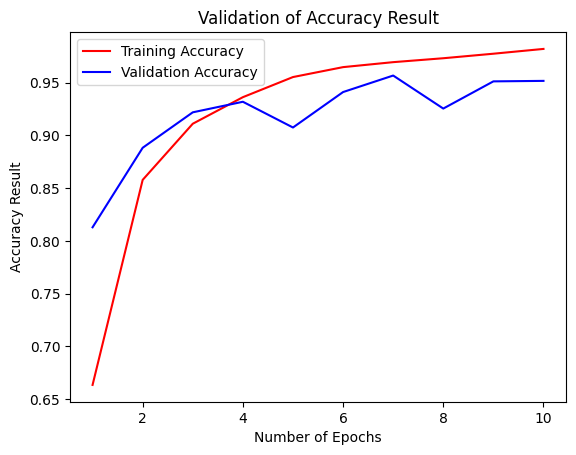

In [29]:
epochs=[i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('Number of Epochs')
plt.ylabel('Accuracy Result')
plt.legend()
plt.title('Validation of Accuracy Result')
plt.show()

### Some other metrics for evaluation

In [30]:
class_name=validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [31]:
test_set=tf.keras.utils.image_dataset_from_directory(
    'dataset-2/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
)

Found 10849 files belonging to 38 classes.


In [32]:
y_pred=model.predict(test_set)
y_pred,y_pred.shape

340/340 [==============================] - 8s 24ms/step


(array([[1.00000000e+00, 6.23721073e-13, 5.30868867e-17, ...,
         1.38762378e-19, 7.77847773e-16, 2.01158030e-16],
        [9.99958634e-01, 3.33798678e-09, 6.87384719e-14, ...,
         1.13257819e-12, 5.98464854e-13, 1.38684113e-08],
        [9.99657273e-01, 1.89430915e-10, 2.56921849e-12, ...,
         2.60628520e-12, 1.10350800e-11, 2.79233359e-10],
        ...,
        [3.98076190e-12, 1.75743412e-14, 5.99520850e-11, ...,
         1.37385615e-11, 5.05609877e-13, 9.99996305e-01],
        [3.11760173e-10, 2.84615925e-11, 1.31705508e-10, ...,
         9.63691149e-13, 2.33071756e-10, 9.96965587e-01],
        [1.37906673e-15, 5.91089303e-17, 3.36141637e-14, ...,
         1.92727778e-15, 6.60443759e-13, 9.99999642e-01]], dtype=float32),
 (10849, 38))

In [33]:
predicted_categories=tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(10849,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [34]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(10849, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [35]:
y_true=tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(10849,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

## Confusion Matrix Visualisation

In [36]:
from sklearn.metrics import classification_report,confusion_matrix

In [37]:
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.76      0.94      0.84       126
                                 Apple___Black_rot       0.89      1.00      0.94       124
                          Apple___Cedar_apple_rust       0.92      0.89      0.91        55
                                   Apple___healthy       0.97      0.87      0.92       329
                               Blueberry___healthy       0.98      0.97      0.98       300
          Cherry_(including_sour)___Powdery_mildew       0.98      0.95      0.97       210
                 Cherry_(including_sour)___healthy       0.84      0.98      0.90       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.67      0.78       102
                       Corn_(maize)___Common_rust_       0.98      0.97      0.98       238
               Corn_(maize)___Northern_Leaf_Blight       0.86      0.98      0.

In [38]:
cm=confusion_matrix(y_true,predicted_categories)
cm

array([[ 119,    2,    0, ...,    0,    0,    0],
       [   0,  124,    0, ...,    0,    0,    0],
       [   0,    1,   49, ...,    0,    0,    0],
       ...,
       [   0,    0,    0, ..., 1061,    0,    0],
       [   0,    0,    0, ...,    0,   72,    0],
       [   0,    0,    0, ...,    0,    0,  316]], dtype=int64)

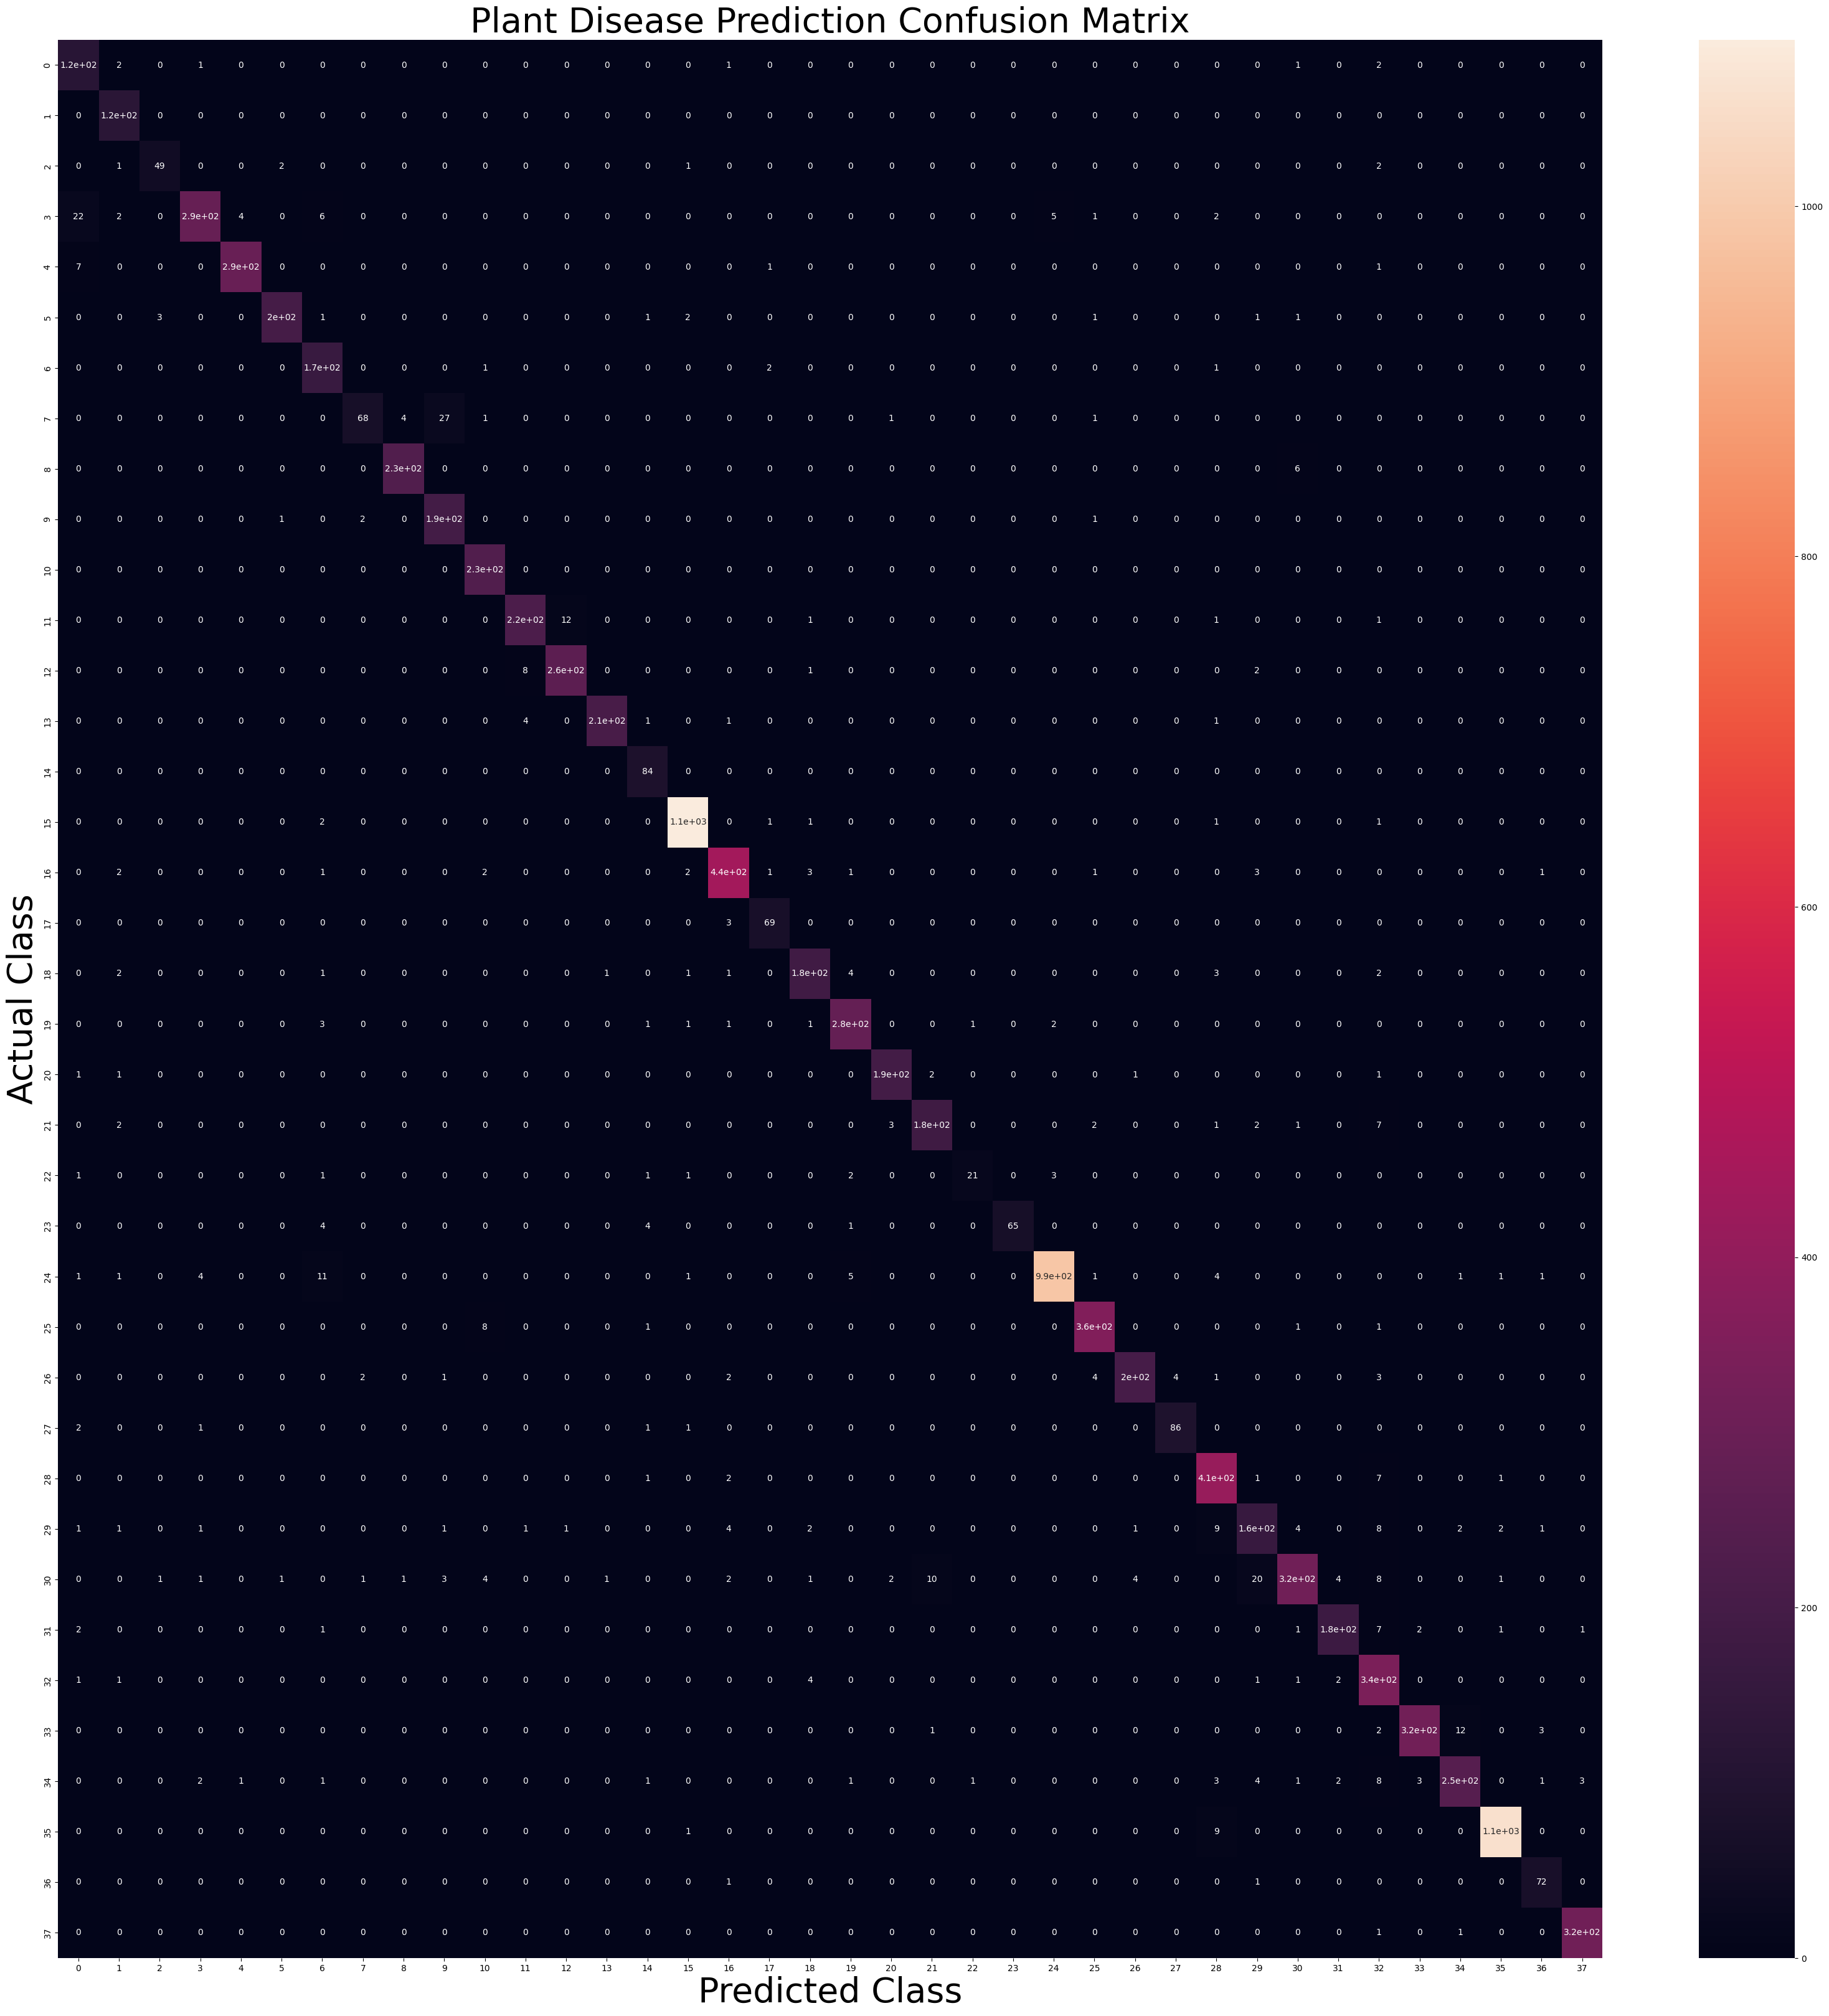

In [39]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel('Predicted Class',fontsize=40)
plt.ylabel('Actual Class',fontsize=40)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize=40)
plt.show()

In [43]:
test_loss, test_acc = model.evaluate(test_set)


340/340 [==============================] - 8s 23ms/step - loss: 0.1685 - accuracy: 0.9523


In [44]:
test_loss,test_acc

(0.16854281723499298, 0.9523458480834961)

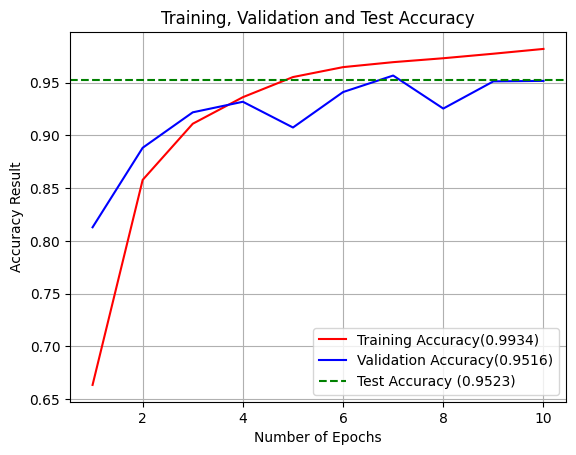

In [49]:
epochs=[i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label=f'Training Accuracy({train_acc:.4f})')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label=f'Validation Accuracy({val_acc:.4f})')
plt.axhline(y=test_acc, color='green', linestyle='--',label=f'Test Accuracy ({test_acc:.4f})')
plt.xlabel('Number of Epochs')
plt.ylabel('Accuracy Result')
plt.legend()
plt.title('Training, Validation and Test Accuracy')
plt.grid(True)
plt.show()

In [ ]:
! git add .


In [ ]:
! git commit -m "training and validation using keras"